In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import sys , os

In [2]:
sys.path.append(os.path.join(os.getcwd(),'..','src'))

In [3]:
from preprocessing import *
from logistic_master import LogisticRegression
from utils import *
print("done")

done


In [4]:
X_ai_train = np.load('../Data/processed/X_ai_train.npy')
X_ai_test  = np.load('../Data/processed/X_ai_test.npy')
y_ai_train = np.load('../Data/processed/y_ai_train.npy')
y_ai_test  = np.load('../Data/processed/y_ai_test.npy')

X_bc_train = np.load('../Data/processed/X_bc_train.npy')
X_bc_test  = np.load('../Data/processed/X_bc_test.npy')
y_bc_train = np.load('../Data/processed/y_bc_train.npy')
y_bc_test  = np.load('../Data/processed/y_bc_test.npy')

X_db_train = np.load('../Data/processed/X_db_train.npy')
X_db_test  = np.load('../Data/processed/X_db_test.npy')
y_db_train = np.load('../Data/processed/y_db_train.npy')
y_db_test  = np.load('../Data/processed/y_db_test.npy')

print(f" AI :{X_ai_train.shape , X_ai_test.shape}" )
print(f"BC : {X_bc_train.shape , X_bc_test.shape}")
print(f" DB : {X_db_train.shape , X_db_test.shape}")

 AI :((26048, 109), (6513, 109))
BC : ((455, 21), (114, 21))
 DB : ((614, 9), (154, 9))


In [7]:
# baseline results
datasets = {
    'Adult Income' : (X_ai_train , X_ai_test , y_ai_train , y_ai_test),
    'Breast Cancer' : (X_bc_train , X_bc_test , y_bc_train , y_bc_test),
    'Diabetes' : (X_db_train , X_db_test , y_db_train , y_db_test)
}
print("Baseline Results (No regularization)")
for name , (X_tr , X_te , y_tr , y_te) in datasets.items():
    model = LogisticRegression()
    model.fit_gd(X_tr , y_tr , alpha = 0.1 , epochs = 1000)

    y_pred = model.predict(X_te)

    acc = compute_accuracy(y_te , y_pred)
    f1 = compute_f1_score(y_te , y_pred)
    mcc = matthews_corrcoef(y_te , y_pred)

    print(f"{name}")
    print(f"accuracy : {acc:.4f}")
    print(f"f1 score : {f1:.4f}")
    print(f"matthews coefficient : {mcc:.4f}")
    print()
    print()

Baseline Results (No regularization)
Adult Income
accuracy : 0.8500
f1 score : 0.9043
matthews coefficient : 0.5663


Breast Cancer
accuracy : 0.9825
f1 score : 0.9855
matthews coefficient : 0.9639


Diabetes
accuracy : 0.7727
f1 score : 0.8223
matthews coefficient : 0.5071




In [8]:
lambdas = [0.001, 0.01, 0.1, 1.0, 10.0]

print("L2 regularization results")
print("="*55)

for name, (X_tr, X_te, y_tr, y_te) in datasets.items():
    print()
    print(f"{name}")
    print(f"  {'Lambda':<10} {'Accuracy':<12} {'F1':<10} {'MCC'}")
    print(f"  {'-'*45}")
    
    for lam in lambdas:
        model = LogisticRegression()
        model.fit_gd(X_tr, y_tr, alpha = 0.1, epochs = 1000,
                     lambda_reg = lam, penalty = 'l2')
        
        y_pred = model.predict(X_te)
        
        acc = compute_accuracy(y_te , y_pred)
        f1  = compute_f1_score(y_te , y_pred)
        mcc = matthews_corrcoef(y_te , y_pred)
        
        print(f"  {lam:<10} {acc:<12.4f} {f1:<10.4f} {mcc:.4f}")

L2 regularization results

Adult Income
  Lambda     Accuracy     F1         MCC
  ---------------------------------------------
  0.001      0.8500       0.9043     0.5663
  0.01       0.8500       0.9043     0.5663
  0.1        0.8500       0.9043     0.5663
  1.0        0.8500       0.9043     0.5663
  10.0       0.8501       0.9044     0.5667

Breast Cancer
  Lambda     Accuracy     F1         MCC
  ---------------------------------------------
  0.001      0.9825       0.9855     0.9639
  0.01       0.9825       0.9855     0.9639
  0.1        0.9825       0.9855     0.9639
  1.0        0.9825       0.9855     0.9639
  10.0       0.9737       0.9781     0.9453

Diabetes
  Lambda     Accuracy     F1         MCC
  ---------------------------------------------
  0.001      0.7727       0.8223     0.5071
  0.01       0.7727       0.8223     0.5071
  0.1        0.7727       0.8223     0.5071
  1.0        0.7727       0.8223     0.5071
  10.0       0.7662       0.8182     0.4912


In [9]:
print("L1 regularizatiion results")
print("="*55)

for name, (X_tr, X_te, y_tr, y_te) in datasets.items():
    print()
    print(f"{name}")
    print(f"  {'Lambda':<10} {'Accuracy':<12} {'F1':<10} {'MCC':<10} {'Zero Weights'}")
    print(f"  {'-'*55}")
    
    for lam in lambdas:
        model = LogisticRegression()
        model.fit_gd(X_tr , y_tr , alpha = 0.1 , epochs = 1000 ,
                     lambda_reg = lam , penalty = 'l1')
        
        y_pred = model.predict(X_te)
        
        acc = compute_accuracy(y_te , y_pred)
        f1  = compute_f1_score(y_te , y_pred)
        mcc = matthews_corrcoef(y_te , y_pred)
        zero_weights = np.sum(np.abs(model.theta[1:]) < 1e-4)
        
        print(f"  {lam:<10} {acc:<12.4f} {f1:<10.4f} {mcc:<10.4f} {zero_weights}")

L1 regularizatiion results

Adult Income
  Lambda     Accuracy     F1         MCC        Zero Weights
  -------------------------------------------------------
  0.001      0.8500       0.9043     0.5663     0
  0.01       0.8500       0.9043     0.5663     0
  0.1        0.8500       0.9043     0.5663     0
  1.0        0.8500       0.9043     0.5663     1
  10.0       0.8498       0.9043     0.5652     7

Breast Cancer
  Lambda     Accuracy     F1         MCC        Zero Weights
  -------------------------------------------------------
  0.001      0.9825       0.9855     0.9639     0
  0.01       0.9825       0.9855     0.9639     0
  0.1        0.9825       0.9855     0.9639     0
  1.0        0.9825       0.9855     0.9639     0
  10.0       0.9474       0.9577     0.8939     1

Diabetes
  Lambda     Accuracy     F1         MCC        Zero Weights
  -------------------------------------------------------
  0.001      0.7727       0.8223     0.5071     0
  0.01       0.7727       0

In [10]:
l1_ratios = [0.2, 0.5, 0.8]
en_lambdas = [0.1, 1.0, 10.0]

print("elastic net ")
print("="*55)

for name, (X_tr, X_te, y_tr, y_te) in datasets.items():
    print()
    print()
    print(f"{name}")
    print(f"  {'Lambda':<10} {'L1 Ratio':<12} {'F1':<10} {'MCC':<10} {'Zero Weights'}")
    print(f"  {'-'*55}")
    
    for lam in en_lambdas:
        for ratio in l1_ratios:
            model = LogisticRegression()
            model.fit_gd(X_tr , y_tr , alpha = 0.1 , epochs = 1000 ,
                         lambda_reg = lam , penalty = 'elasticnet' ,
                         l1_ratio = ratio)
            
            y_pred = model.predict(X_te)
            
            f1  = compute_f1_score(y_te , y_pred)
            mcc = matthews_corrcoef(y_te , y_pred)
            zero_weights = np.sum(np.abs(model.theta[1:]) < 1e-4)
            
            print(f"  {lam:<10} {ratio:<12} {f1:<10.4f} {mcc:<10.4f} {zero_weights}")
        print()
        print()

elastic net 


Adult Income
  Lambda     L1 Ratio     F1         MCC        Zero Weights
  -------------------------------------------------------
  0.1        0.2          0.9043     0.5663     0
  0.1        0.5          0.9043     0.5663     0
  0.1        0.8          0.9043     0.5663     0


  1.0        0.2          0.9044     0.5667     0
  1.0        0.5          0.9044     0.5667     1
  1.0        0.8          0.9043     0.5663     1


  10.0       0.2          0.9043     0.5662     2
  10.0       0.5          0.9044     0.5665     3
  10.0       0.8          0.9043     0.5659     6




Breast Cancer
  Lambda     L1 Ratio     F1         MCC        Zero Weights
  -------------------------------------------------------
  0.1        0.2          0.9855     0.9639     0
  0.1        0.5          0.9855     0.9639     0
  0.1        0.8          0.9855     0.9639     0


  1.0        0.2          0.9855     0.9639     0
  1.0        0.5          0.9855     0.9639     0
  1.0     

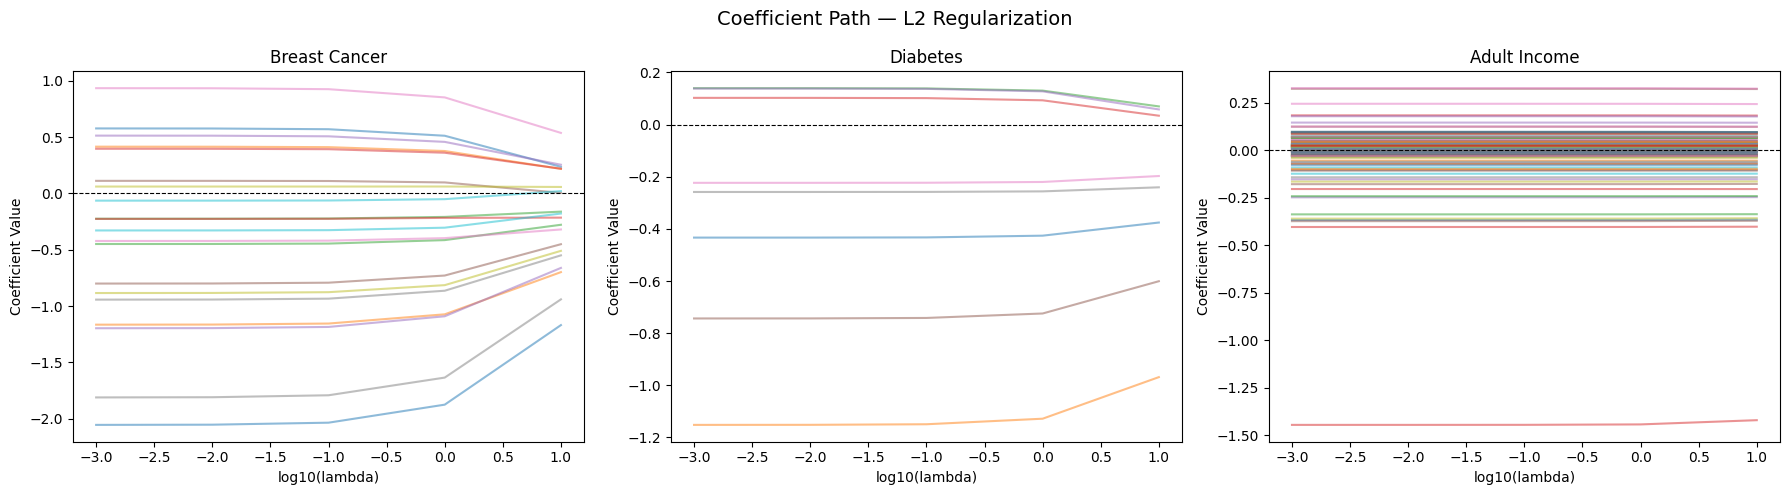

Saved.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Coefficient Path — L2 Regularization', fontsize=14)

dataset_list = [
    ('Breast Cancer', X_bc_train, y_bc_train),
    ('Diabetes',      X_db_train, y_db_train),
    ('Adult Income',  X_ai_train, y_ai_train)
]

lambdas_path = [0.001, 0.01, 0.1, 1.0, 10.0]

for ax, (name, X_tr, y_tr) in zip(axes, dataset_list):
    coef_paths = []
    
    for lam in lambdas_path:
        model = LogisticRegression()
        model.fit_gd(X_tr, y_tr, alpha=0.1, epochs=1000,
                     lambda_reg=lam, penalty='l2')
        coef_paths.append(model.theta[1:].flatten())
    
    coef_paths = np.array(coef_paths)  
    
    for j in range(coef_paths.shape[1]):
        ax.plot(np.log10(lambdas_path), coef_paths[:, j], alpha=0.5)
    
    ax.set_title(name)
    ax.set_xlabel('log10(lambda)')
    ax.set_ylabel('Coefficient Value')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('../Results/figures/coefficient_path_l2.png', dpi=150)
plt.show()
print("Saved.")

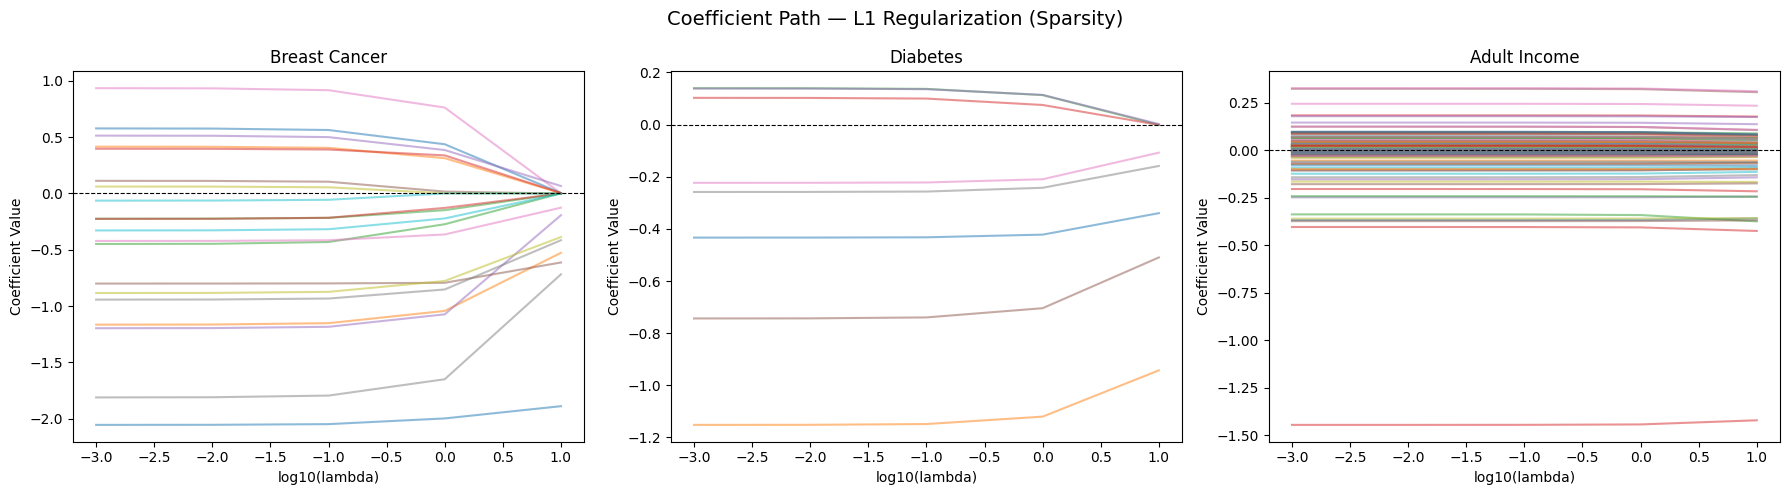

Saved.


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Coefficient Path — L1 Regularization (Sparsity)', fontsize=14)

for ax, (name, X_tr, y_tr) in zip(axes, dataset_list):
    coef_paths = []
    
    for lam in lambdas_path:
        model = LogisticRegression()
        model.fit_gd(X_tr, y_tr, alpha=0.1, epochs=1000,
                     lambda_reg=lam, penalty='l1')
        coef_paths.append(model.theta[1:].flatten())
    
    coef_paths = np.array(coef_paths)  # shape (5, n_features)
    
    for j in range(coef_paths.shape[1]):
        ax.plot(np.log10(lambdas_path), coef_paths[:, j], alpha=0.5)
    
    ax.set_title(name)
    ax.set_xlabel('log10(lambda)')
    ax.set_ylabel('Coefficient Value')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('../Results/figures/coefficient_path_l1.png', dpi=150)
plt.show()
print("Saved.")

In [14]:
!pip install tabulate

In [15]:
from tabulate import tabulate

results = []

configs = [
    ('No Reg',          0.0,   None,         0.5),
    ('L2 λ=0.001',      0.001, 'l2',         0.5),
    ('L2 λ=1.0',        1.0,   'l2',         0.5),
    ('L1 λ=0.001',      0.001, 'l1',         0.5),
    ('L1 λ=10.0',       10.0,  'l1',         0.5),
    ('EN λ=1.0 r=0.5',  1.0,   'elasticnet', 0.5),
    ('EN λ=10.0 r=0.8', 10.0,  'elasticnet', 0.8),
]

for name, (X_tr, X_te, y_tr, y_te) in datasets.items():
    for config_name, lam, penalty, ratio in configs:
        model = LogisticRegression()
        model.fit_gd(X_tr, y_tr, alpha=0.1, epochs=1000,
                     lambda_reg=lam, penalty=penalty, l1_ratio=ratio)
        
        y_pred = model.predict(X_te)
        
        f1  = compute_f1_score(y_te, y_pred)
        mcc = matthews_corrcoef(y_te, y_pred)
        zeros = np.sum(np.abs(model.theta[1:]) < 1e-4)
        
        results.append([name, config_name, f"{f1:.4f}", f"{mcc:.4f}", zeros])

headers = ['Dataset', 'Config', 'F1', 'MCC', 'Zero Weights']
print(tabulate(results, headers=headers, tablefmt='grid'))

+---------------+-----------------+--------+--------+----------------+
| Dataset       | Config          |     F1 |    MCC |   Zero Weights |
+===============+=================+========+========+================+
| Adult Income  | No Reg          | 0.9043 | 0.5663 |              0 |
+---------------+-----------------+--------+--------+----------------+
| Adult Income  | L2 λ=0.001      | 0.9043 | 0.5663 |              0 |
+---------------+-----------------+--------+--------+----------------+
| Adult Income  | L2 λ=1.0        | 0.9043 | 0.5663 |              0 |
+---------------+-----------------+--------+--------+----------------+
| Adult Income  | L1 λ=0.001      | 0.9043 | 0.5663 |              0 |
+---------------+-----------------+--------+--------+----------------+
| Adult Income  | L1 λ=10.0       | 0.9043 | 0.5652 |              7 |
+---------------+-----------------+--------+--------+----------------+
| Adult Income  | EN λ=1.0 r=0.5  | 0.9044 | 0.5667 |              1 |
+-----

# Phase V — Regularization

## Objective
Extend LogisticRegression to support L1, L2, and Elastic Net regularization.
Study coefficient shrinkage, sparsity, and generalization across 3 datasets.

---

## Changes Made to `logistic_master.py`

- `compute_cost` — added penalty term (L1, L2, ElasticNet)
- `fit_gd` — added regularization to gradient with bias protection
- `fit_newton` — same regularization added to gradient
- Bias term (theta[0]) never penalized in any penalty type

New signatures:
```python
compute_cost(self, X, y, theta, lambda_reg=0.0, penalty=None, l1_ratio=0.5)
fit_gd(self, X, y, alpha=0.01, epochs=1000, lambda_reg=0.0, penalty=None, l1_ratio=0.5)
fit_newton(self, X, y, max_iter=100, tol=1e-6, lambda_reg=0.0, penalty=None, l1_ratio=0.5)
```

---

## Datasets Used
| Dataset | Samples | Features | Why Chosen |
|---|---|---|---|
| Breast Cancer | 569 | 21 | Multicollinearity, well separated |
| Diabetes | 768 | 9 | Small, noisy, moderate imbalance |
| Adult Income | 32,561 | 109 | High dimensional, heavy encoding |

---

## Baseline Results (No Regularization)
| Dataset | F1 | MCC |
|---|---|---|
| Adult Income | 0.9043 | 0.5663 |
| Breast Cancer | 0.9855 | 0.9639 |
| Diabetes | 0.8223 | 0.5071 |

---

## L2 Results
- No improvement on any dataset at low lambdas (0.001 → 1.0)
- Lambda 10.0 hurts Breast Cancer (MCC 0.9639 → 0.9453) and Diabetes (MCC 0.5071 → 0.4912)
- Adult Income tiny improvement at lambda 10.0 (MCC 0.5663 → 0.5667)
- **Conclusion:** These datasets are not overfitting. L2 adds nothing meaningful.

---

## L1 Results
| Dataset | Lambda | F1 | MCC | Zero Weights |
|---|---|---|---|---|
| Adult Income | 10.0 | 0.9043 | 0.5652 | 7 |
| Breast Cancer | 10.0 | 0.9577 | 0.8939 | 1 |
| Diabetes | 10.0 | 0.8283 | 0.5195 | 0 |

- Adult Income — 7 features zeroed out, performance stable. L1 doing feature selection.
- Breast Cancer — 1 feature zeroed, performance drops. All features are meaningful here.
- Diabetes — no zeros but MCC improves (0.5071 → 0.5195). L1 reducing noise without full zeroing.

---

## Elastic Net Results
| Dataset | Lambda | L1 Ratio | F1 | MCC | Zero Weights |
|---|---|---|---|---|---|
| Adult Income | 10.0 | 0.8 | 0.9043 | 0.5659 | 6 |
| Breast Cancer | 1.0 | 0.5 | 0.9855 | 0.9639 | 0 |
| Diabetes | 1.0 | 0.5 | 0.8223 | 0.5071 | 0 |

- Higher L1 ratio = more sparsity on Adult Income (confirmed)
- L2 component protects Breast Cancer from aggressive shrinkage
- Diabetes stable across all Elastic Net configs

---

## Key Findings

1. **Regularization only helps when overfitting exists.** These datasets are clean
   enough that baseline GD already generalizes well.

2. **L1 proves sparsity on high dimensional data.** Adult Income loses 7 of 108
   features at lambda=10 with no performance drop. Feature selection works.

3. **Breast Cancer needs no regularization.** Every feature carries signal.
   Aggressive L1 hurts. Best left unregularized.

4. **Diabetes benefits slightly from L1.** MCC improves 0.5071 → 0.5195.
   Small noisy datasets respond to gentle coefficient shrinkage.

5. **Bias term must never be regularized.** Implemented correctly via
   reg_term[0] = 0 in both fit_gd and fit_newton.

---

## Best Configuration Per Dataset
| Dataset | Best Penalty | Best Lambda | F1 | MCC |
|---|---|---|---|---|
| Adult Income | Elastic Net | λ=1.0, ratio=0.5 | 0.9044 | 0.5667 |
| Breast Cancer | None | — | 0.9855 | 0.9639 |
| Diabetes | L1 | λ=10.0 | 0.8283 | 0.5195 |

---

## Plots Generated
- `Results/figures/coefficient_path_l2.png` — L2 smooth shrinkage
- `Results/figures/coefficient_path_l1.png` — L1 sparsity (snap to zero)

---

